ссылка на дата сет - https://www.kaggle.com/datasets/syedaeman2212/global-cars-data?select=global_cars_dataset_synthetic.csv

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # устанавливаем seaborn по умолчанию для отрисовки графиков

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
train = pd.read_csv('global_cars_dataset_synthetic.csv')

In [92]:
train.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,0.0,1.0,2.0,3.0
0,0.0,Mercedes,2006,3.0,3.0,1.0,4089,547,17,73407,5.0,0.0,0.0,0.0,1.0
1,1.0,Nissan,2023,0.0,3.0,0.0,4618,167,25,79370,5.0,0.0,0.0,0.0,1.0
2,2.0,Nissan,2007,1.0,0.0,1.0,1802,110,16,76549,0.0,1.0,0.0,0.0,0.0
3,3.0,Nissan,2013,0.0,3.0,1.0,1835,373,16,48722,5.0,0.0,0.0,0.0,1.0
4,4.0,Hyundai,2009,1.0,2.0,0.0,2332,145,28,83265,4.0,0.0,0.0,1.0,0.0



Car_ID - Идентификатор	Уникальный идентификационный номер автомобиля (например, CAR_0001)

Brand	- Марка / Бренд	Производитель автомобиля (например, Mercedes, Nissan)

Manufacture_Year - Год выпуска	Год производства автомобиля

Body_Type -	Тип кузова	Конструкция кузова (SUV, Coupe, Hatchback, Sedan и т.д.)

Fuel_Type -	Тип топлива	Вид используемого топлива (Petrol, Diesel, Hybrid, Electric)

Transmission - Коробка передач	Тип трансмиссии (Manual, Automatic, CVT)

Engine_CC -	Объём двигателя	Рабочий объём двигателя в кубических сантиметрах
Horsepower	Мощность (л.с.)

Mileage_km_per_l - Расход топлив (км/л)	Топливная экономичность (сколько километров на литре топлива)

Price_USD -	Цена (USD)	Стоимость автомобиля в долларах США

Manufacturing_Country	- Страна-производитель

In [75]:
train.describe()

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2015.123333,3052.880000,328.346667,19.716667,60848.823333
std,5.966023,1117.937497,153.202644,6.028061,34445.525598
min,2005.000000,1001.000000,70.000000,10.000000,5221.000000
25%,2010.000000,2074.000000,188.250000,15.000000,29418.500000
50%,2015.000000,3117.500000,329.500000,19.500000,59179.500000
75%,2020.000000,3964.000000,454.750000,24.000000,89692.250000
max,2025.000000,4994.000000,599.000000,30.000000,119587.000000


  анализ зависимостей между характеристиками и ценой

In [76]:
train.describe(include=['O'])

,Car_ID,Brand,Body_Type,Fuel_Type,Transmission,Manufacturing_Country
count,300,300,300,300,300,300
unique,300,10,5,4,2,6
top,CAR_0300,Nissan,Sedan,Petrol,Manual,Germany
freq,1,41,70,77,155,55


count - количество непустых значений

unique - количество уникальных записей.

top - наиболее часто повторяющаяся запись.

freq - частота самой частой записи.

Germany — главный страна-производитель в выборке.

In [77]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Car_ID                 300 non-null    object
 1   Brand                  300 non-null    object
 2   Manufacture_Year       300 non-null    int64 
 3   Body_Type              300 non-null    object
 4   Fuel_Type              300 non-null    object
 5   Transmission           300 non-null    object
 6   Engine_CC              300 non-null    int64 
 7   Horsepower             300 non-null    int64 
 8   Mileage_km_per_l       300 non-null    int64 
 9   Price_USD              300 non-null    int64 
 10  Manufacturing_Country  300 non-null    object
dtypes: int64(5), object(6)
memory usage: 25.9+ KB


In [78]:
train.isnull().sum()

,0
Car_ID,0
Brand,0
Manufacture_Year,0
Body_Type,0
Fuel_Type,0
Transmission,0
Engine_CC,0
Horsepower,0
Mileage_km_per_l,0
Price_USD,0


все значения заполнены

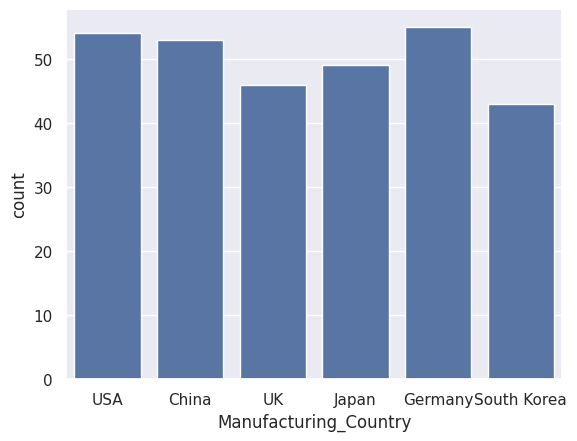

In [79]:
sns.countplot(x=train["Manufacturing_Country"]);

In [ ]:
зависимосчть кол-ва от Страны-производителя

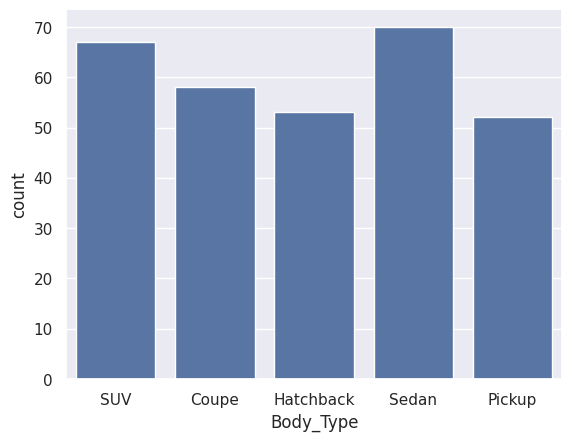

In [80]:
sns.countplot(x=train["Body_Type"]);

In [ ]:
зависимосчть кол-ва от Типа кузова

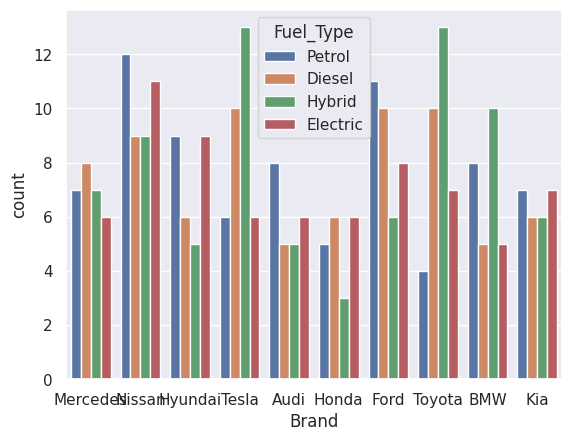

In [81]:
sns.countplot(data=train, x='Brand', hue='Fuel_Type');

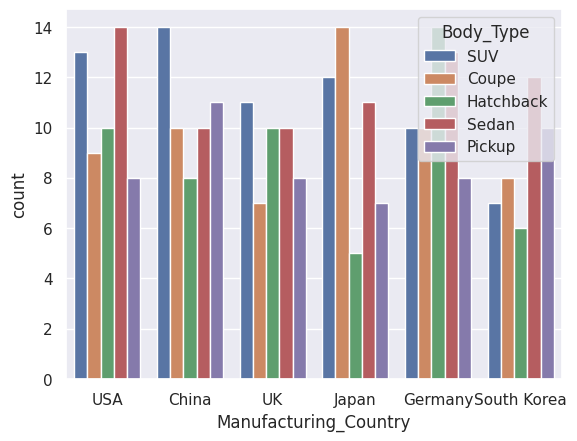

In [82]:
sns.countplot(data=train, x="Manufacturing_Country", hue='Body_Type');

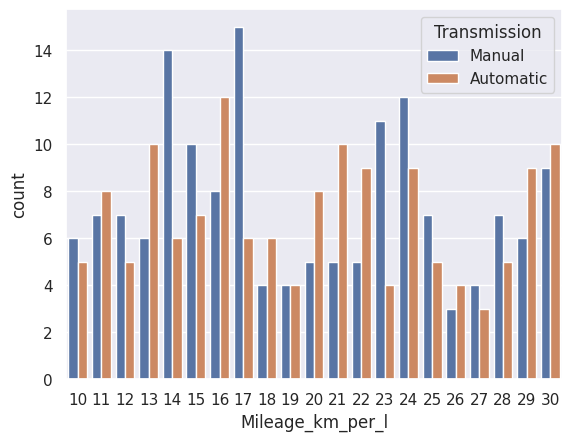

In [84]:
sns.countplot(data=train, x="Mileage_km_per_l", hue='Transmission');

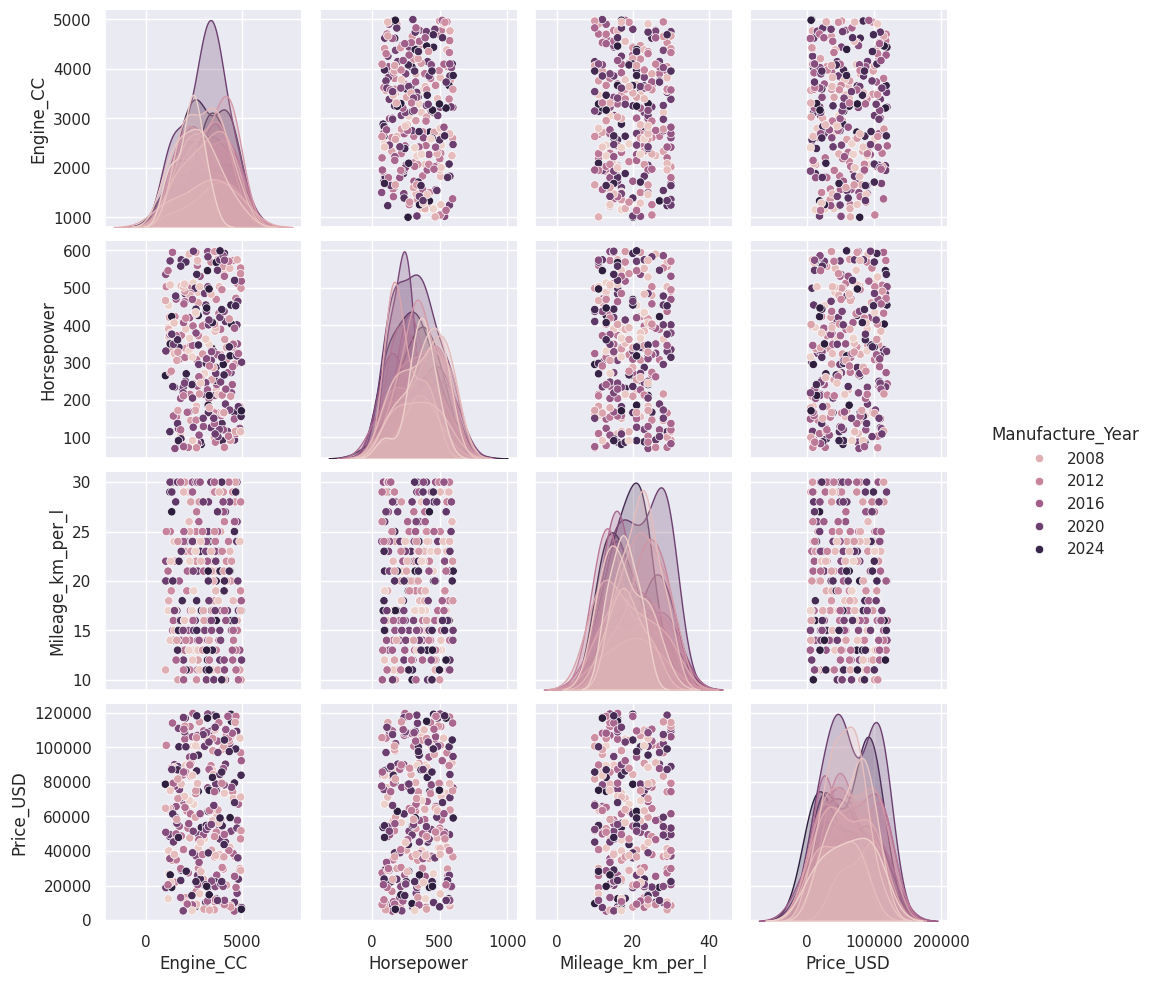

In [69]:
sns.pairplot(train, kind="scatter", hue="Manufacture_Year");

In [85]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
train[[ 'Body_Type','Car_ID','Fuel_Type','Transmission', 'Manufacturing_Country']] = enc.fit_transform(train[['Body_Type','Car_ID','Fuel_Type','Transmission','Manufacturing_Country']])
train.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
0,0.0,Mercedes,2006,3.0,3.0,1.0,4089,547,17,73407,5.0
1,1.0,Nissan,2023,0.0,3.0,0.0,4618,167,25,79370,5.0
2,2.0,Nissan,2007,1.0,0.0,1.0,1802,110,16,76549,0.0
3,3.0,Nissan,2013,0.0,3.0,1.0,1835,373,16,48722,5.0
4,4.0,Hyundai,2009,1.0,2.0,0.0,2332,145,28,83265,4.0


sklearn.preprocessing.OrdinalEncoder раздает категориальным признакам значения от 0 до  n , где  n  - это количество различных значений в данном столбце.

In [86]:
enc.categories_

[array(['Coupe', 'Hatchback', 'Pickup', 'SUV', 'Sedan'], dtype=object),
 array(['CAR_0001', 'CAR_0002', 'CAR_0003', 'CAR_0004', 'CAR_0005',
        'CAR_0006', 'CAR_0007', 'CAR_0008', 'CAR_0009', 'CAR_0010',
        'CAR_0011', 'CAR_0012', 'CAR_0013', 'CAR_0014', 'CAR_0015',
        'CAR_0016', 'CAR_0017', 'CAR_0018', 'CAR_0019', 'CAR_0020',
        'CAR_0021', 'CAR_0022', 'CAR_0023', 'CAR_0024', 'CAR_0025',
        'CAR_0026', 'CAR_0027', 'CAR_0028', 'CAR_0029', 'CAR_0030',
        'CAR_0031', 'CAR_0032', 'CAR_0033', 'CAR_0034', 'CAR_0035',
        'CAR_0036', 'CAR_0037', 'CAR_0038', 'CAR_0039', 'CAR_0040',
        'CAR_0041', 'CAR_0042', 'CAR_0043', 'CAR_0044', 'CAR_0045',
        'CAR_0046', 'CAR_0047', 'CAR_0048', 'CAR_0049', 'CAR_0050',
        'CAR_0051', 'CAR_0052', 'CAR_0053', 'CAR_0054', 'CAR_0055',
        'CAR_0056', 'CAR_0057', 'CAR_0058', 'CAR_0059', 'CAR_0060',
        'CAR_0061', 'CAR_0062', 'CAR_0063', 'CAR_0064', 'CAR_0065',
        'CAR_0066', 'CAR_0067', 'CAR_0068', 